# TP 5.1 : Classification avec R

## 1. Données `body` allégées

Nous considérons une nouvelles fois les données `body`.

In [9]:
data_body <- read.table("data/body.csv", header=TRUE, sep=";", dec=",", row.names=1)

head(data_body)

,T.epaule,T.poitrine,T.taille,Masse,Taille
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
H1,106.2,89.5,71.5,65.6,174.0
H2,110.5,97.0,79.0,71.8,175.3
H3,115.1,97.5,83.2,80.7,193.5
H4,104.5,97.0,77.8,72.6,186.5
H5,107.5,97.5,80.0,78.8,187.2
H6,119.8,99.9,82.5,74.8,181.5


### 1.1 Classification ascendante hiérarchique

Grâce à la fonction `dist()`, il est possible de calculer les distances euclidiennes entre toutes les paires d'individus.

In [15]:
distances <- dist(data_body)

<div class="alert alert-block alert-success">
    Quelle est la longueur de l'objet créé ? À quoi correspond cette valeur ?
</div>

la taille vaut 190 :
On a une matrice de taille n*n avec des coeff nuls sur la diagonale et sur la partie supérieure

Somme des paires : $\sum_{k=2}^{n=20}k-1 = \frac{n*(n-1)}{2} = 190$

La fonction `hclust()` permet de mettre en oeuvre une classification ascendante hiérarchique à partir de l'objet `distances` et le dendrogramme correspondant s'affiche avec `plot()`.

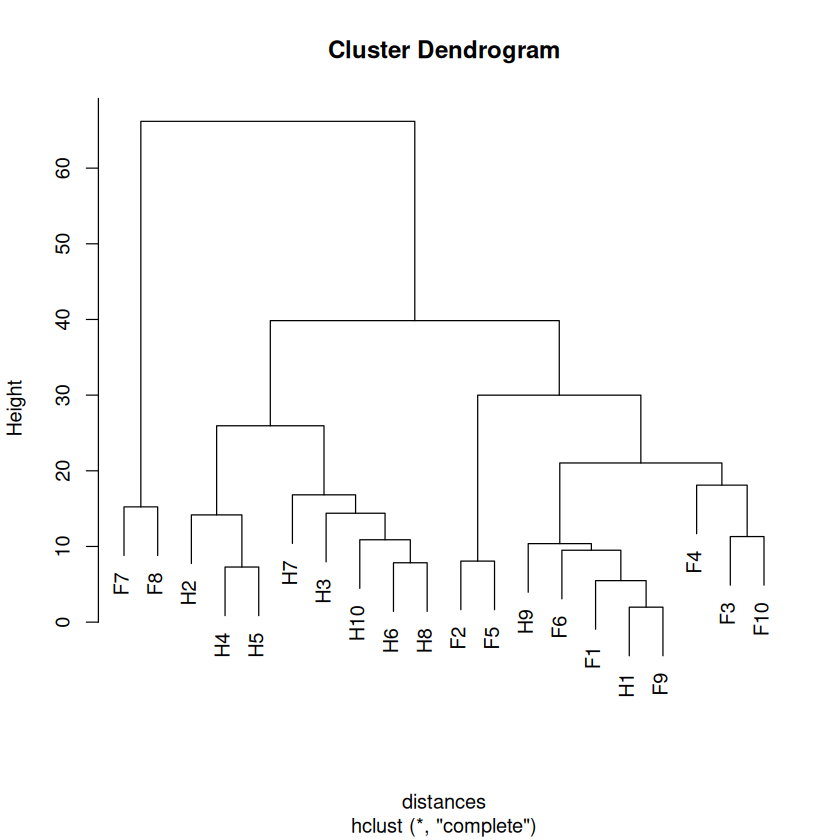

In [18]:
cah_body <- hclust(distances)

par(bg = "white")
plot(cah_body)

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Quel critère d'agglomération est utilisé par défaut par la fonction <code>hclust()</code> ?</li>
        <li>Mettre en oeuvre une classification ascendante hiérarchique en utilisant le critère de Ward comme critère d'agglomération.</li>
        <li>Représenter le dendrogramme associé aux résultats de cette classification.</li>
        <li>En utilisant <code>cah_body&dollar;height</code>, proposer un nombre de groupes raisonnable pour répartir les individus ?</li>
        <li>Utiliser la fonction <code>cutree()</code> avec le nombre de groupes souhaités pour associer chaque individu à un groupe. Les groupes peuvent être visualisés sur le dendrogramme en utilisant la fonction <code>rect.hclust()</code> et l'option <code>border=</code> pour les couleurs.<br>
            <center><img src="img/cah_body.png"></center></li>
        <li>Calculer une ACP des données <code>body</code> et représenter les individus dans le plan principal en donnant une couleur identique aux individus d'un même groupe de votre classification.<br>
            <center><img src="img/cah_acp_body.png"></center></li>
    </ol>
</div>

<span style="color: skyblue; font-weight: bold;"> Question 1</span>

La méthode par défaut est la complete, qui correspond au Maximum de similtidue dans le cour

In [26]:
help(hclust)

hclust                  package:stats                  R Documentation

_H_i_e_r_a_r_c_h_i_c_a_l _C_l_u_s_t_e_r_i_n_g

_D_e_s_c_r_i_p_t_i_o_n:

     Hierarchical cluster analysis on a set of dissimilarities and
     methods for analyzing it.

_U_s_a_g_e:

     hclust(d, method = "complete", members = NULL)
     
     ## S3 method for class 'hclust'
     plot(x, labels = NULL, hang = 0.1, check = TRUE,
          axes = TRUE, frame.plot = FALSE, ann = TRUE,
          main = "Cluster Dendrogram",
          sub = NULL, xlab = NULL, ylab = "Height", ...)
     
_A_r_g_u_m_e_n_t_s:

       d: a dissimilarity structure as produced by ‘dist’.

  method: the agglomeration method to be used.  This should be (an
          unambiguous abbreviation of) one of ‘"ward.D"’, ‘"ward.D2"’,
          ‘"single"’, ‘"complete"’, ‘"average"’ (= UPGMA), ‘"mcquitty"’
          (= WPGMA), ‘"median"’ (= WPGMC) or ‘"centroid"’ (= UPGMC).

 members: ‘NULL’ or a vector w

<span style="color: skyblue; font-weight: bold;"> Question 2 & 3</span>

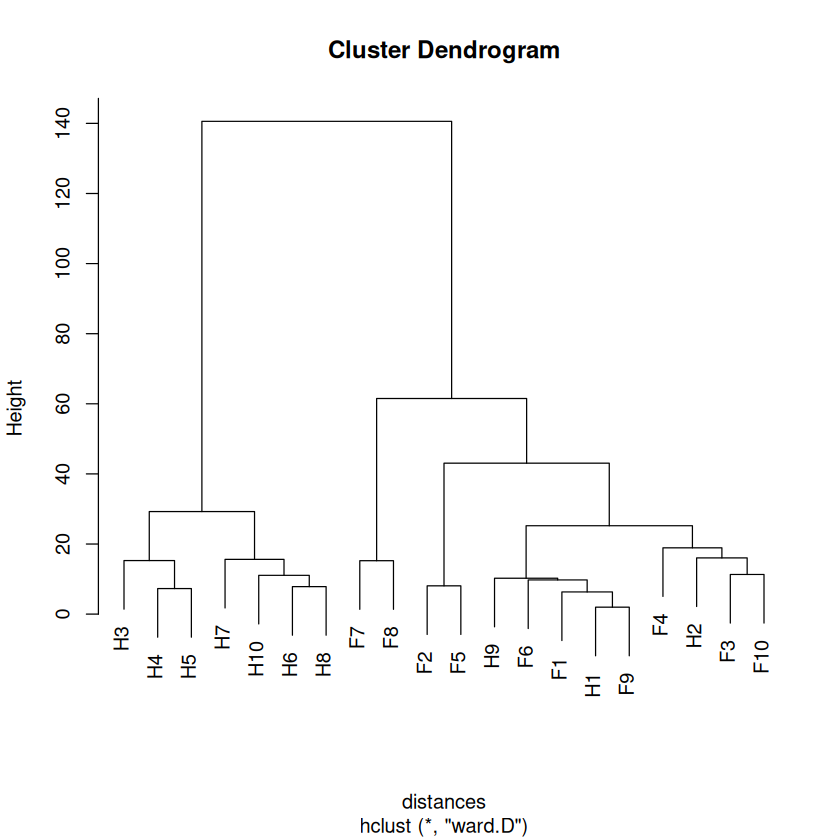

In [40]:
cah_body <- hclust(distances, method = "ward.D")

par(bg = "white")
plot(ward_cah_body)

<span style="color: skyblue; font-weight: bold;"> Question 4</span>

Height affiche les valeurs du critère cumulé. UN histogramme n'est pas pertinent : il faut faire un plot et regarder les sauts verticaux qui correspndent à un nouveau cluster

[1]   1.974842   6.326064   7.281483   7.846655   8.064118   9.750956
 [7]  10.237059  11.064691  11.310172  15.233516  15.280674  15.619757
[13]  16.037836  18.913815  25.215835  29.253569  43.061041  61.515924
[19] 140.587449

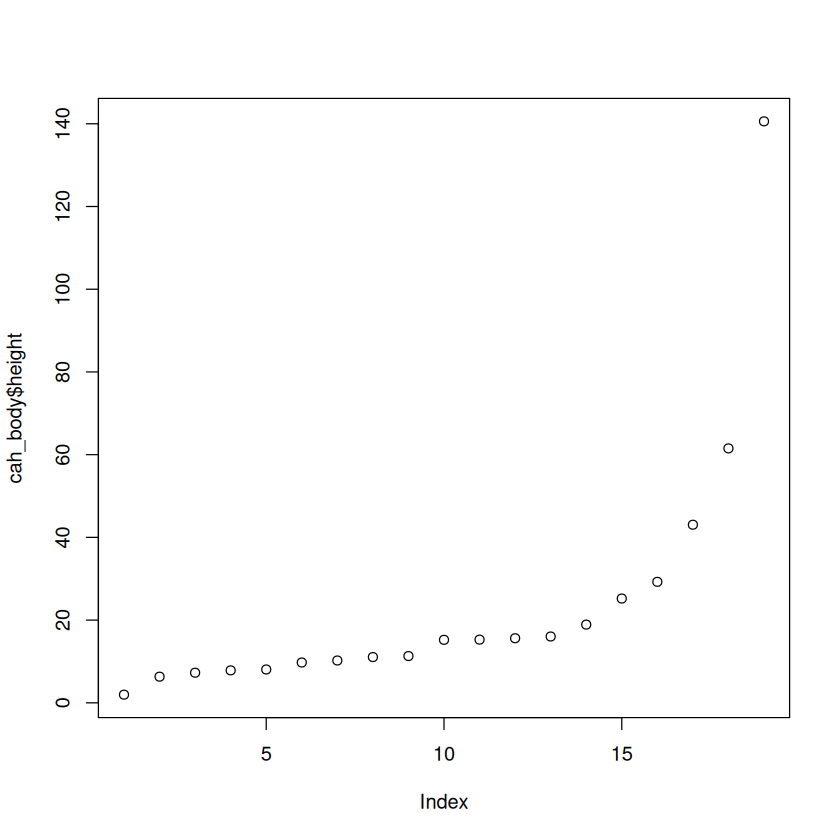

In [39]:
par(bg = "white")
cah_body$height

plot(cah_body$height)

<span style="color: skyblue; font-weight: bold;"> Question 5</span>

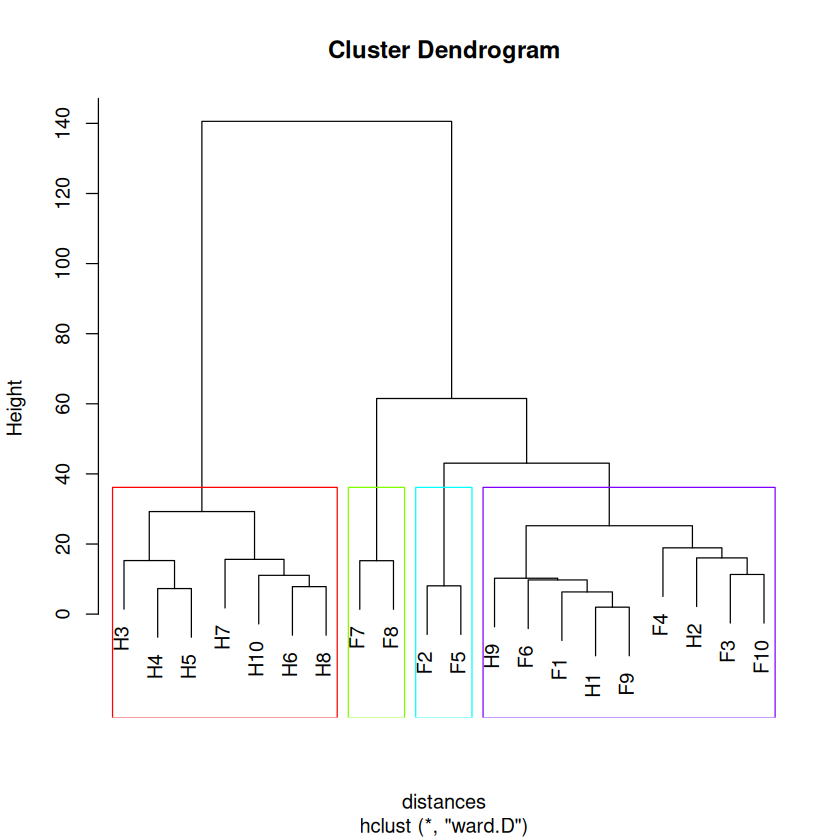

In [43]:
tree <- cutree(cah_body, k=4)

par(bg="white")

plot(cah_body)
rect.hclust(cah_body, k=4, border=rainbow(4))

<span style="color: skyblue; font-weight: bold;"> Question 6</span>

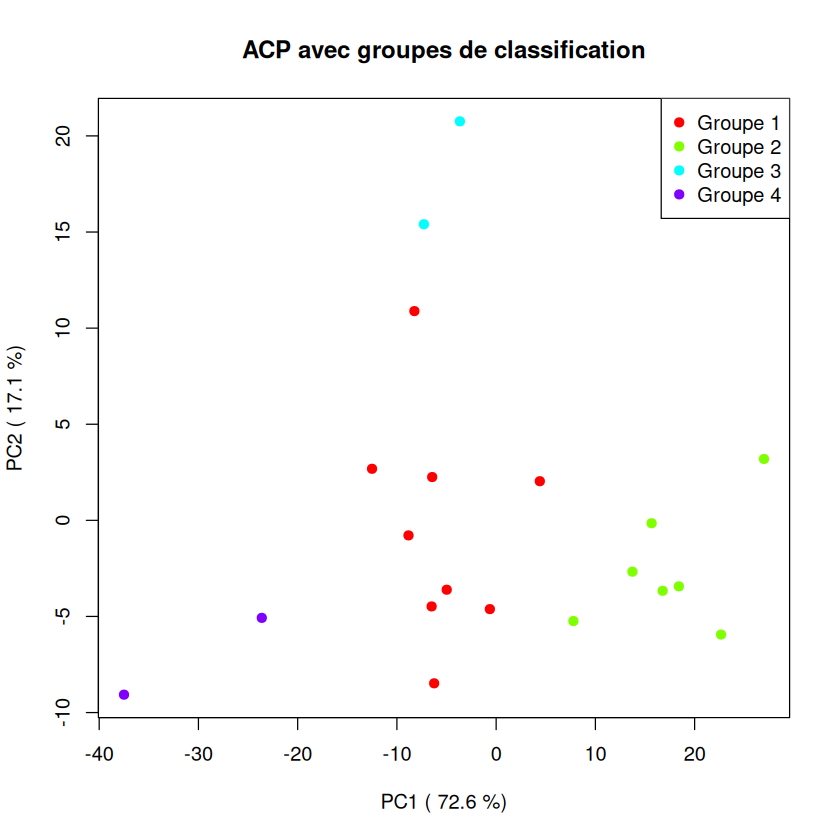

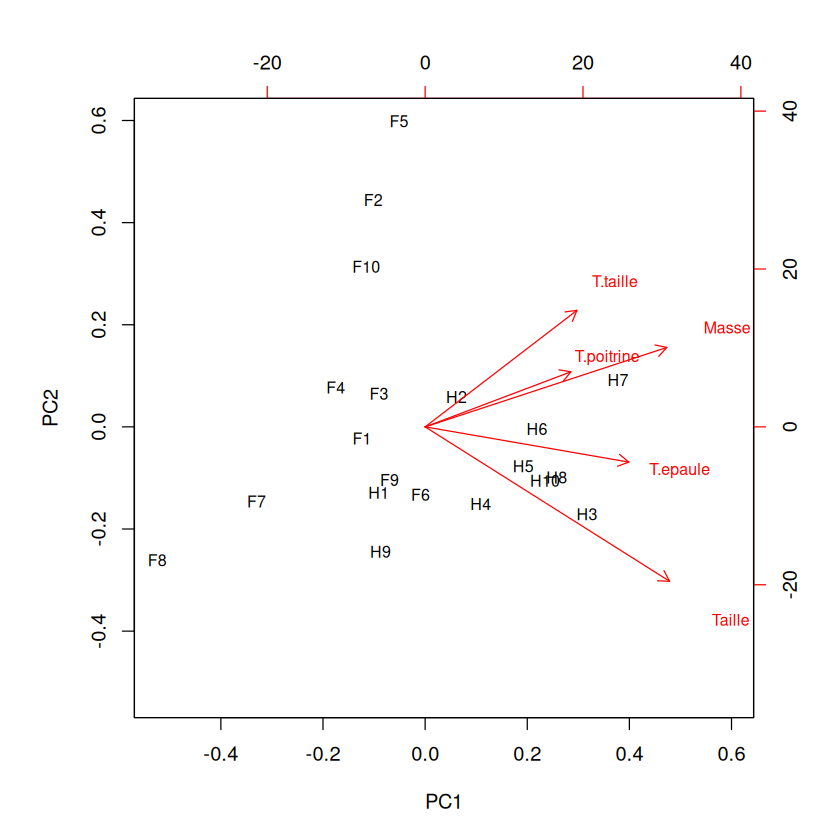

In [ ]:
acp_body <- prcomp(data_body)

par(bg = "white")

# Méthode 1: Utiliser plot() avec les couleurs des groupes
plot(acp_body$x[,1], acp_body$x[,2], 
     col = rainbow(4)[tree], 
     pch = 19,
     xlab = paste("PC1 (", round(summary(acp_body)$importance[2,1]*100, 1), "%)"),
     ylab = paste("PC2 (", round(summary(acp_body)$importance[2,2]*100, 1), "%)"),
     main = "ACP avec groupes de classification")

# Ajouter une légende
legend("topright", 
       legend = paste("Groupe", 1:4), 
       col = rainbow(4), 
       pch = 19)

### 1.2 K-means

Pour réaliser un algorithme K-means, il est possible d'utiliser la fonction `kmeans()` avec l'option `centers=` pour définir un nombre entier de groupes.

In [49]:
# Exemple de K-means à 4 groupes
kmeans_body_1 <- kmeans(data_body, centers=4)
cat("Groupes des individus pour le premier K-means :\n")
print(kmeans_body_1$cluster)

# Un autre exemple de K-means à 4 groupes
kmeans_body_2 <- kmeans(data_body, centers=4)
cat("Groupes des individus pour le second K-means :\n")
print(kmeans_body_2$cluster)

Groupes des individus pour le premier K-means :
 H1  H2  H3  H4  H5  H6  H7  H8  H9 H10  F1  F2  F3  F4  F5  F6  F7  F8  F9 F10 
  2   4   1   4   4   1   1   1   2   1   2   3   3   2   3   4   2   2   2   3 
 H1  H2  H3  H4  H5  H6  H7  H8  H9 H10  F1  F2  F3  F4  F5  F6  F7  F8  F9 F10 
  2   4   1   4   4   1   1   1   2   1   2   3   3   2   3   4   2   2   2   3 
Groupes des individus pour le second K-means :
 H1  H2  H3  H4  H5  H6  H7  H8  H9 H10  F1  F2  F3  F4  F5  F6  F7  F8  F9 F10 
  3   3   1   1   1   1   1   1   3   1   3   4   3   3   4   3   2   2   3   4 
Groupes des individus pour le second K-means :
 H1  H2  H3  H4  H5  H6  H7  H8  H9 H10  F1  F2  F3  F4  F5  F6  F7  F8  F9 F10 
  3   3   1   1   1   1   1   1   3   1   3   4   3   3   4   3   2   2   3   4 


<div class="alert alert-block alert-success">
    Expliquer pourquoi les résultats obtenus sont différents.
</div>

->  les kmeans dépendent beaucoup de l'initialisation

Il est possible de construire la table de contingence qui croise les effectifs des 4 groupes obtenus dans les 2 cas avec la fonction `table()`.

In [50]:
table(kmeans_body_1$cluster, kmeans_body_2$cluster, dnn=c("kmeans1", "kmeans2"))

       kmeans2
kmeans1 1 2 3 4
      1 5 0 0 0
      2 0 2 5 0
      3 0 0 1 3
      4 2 0 2 0

<div class="alert alert-block alert-success">
    Croiser également l'un des résultats obtenus avec les groupes issus de la classification ascendante hiérarchique.
</div>

In [52]:

table(kmeans_body_1$cluster, tree, dnn=c("kmeans1", "tree"))

       tree
kmeans1 1 2 3 4
      1 0 5 0 0
      2 5 0 0 2
      3 2 0 2 0
      4 2 2 0 0

Afin de pallier l'aspect aléatoire de l'algorithme K-means et de stabiliser le résultat d'une classification ascendante hiérarchique, nous pouvons imposer les centres initiaux du K-means comme étant ceux donnés par les groupes de la CAH.

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Calculer les barycentres des classes issues de la classification hiérarchique ascendante et stocker ces résultats en ligne dans une matrice à 5 colonnes.</li>
        <li>Passer cette matrice à l'option <code>centers=</code> de la fonction <code>kmeans()</code>. Est-ce que le résultat est encore aléatoire ?</li>
        <li>Comparer les résultats de cette classification avec ceux de la classification ascendante hiérarchique sous forme d'une table puis sous forme graphique dans le plan principal.</li>
    </ol>
</div>

   
    1 2 3 4
  1 8 0 0 0
  2 0 7 0 0
  3 0 0 3 0
  4 0 0 0 2

   tree
    1 2 3 4
  1 8 0 0 0
  2 0 7 0 0
  3 1 0 2 0
  4 0 0 0 2

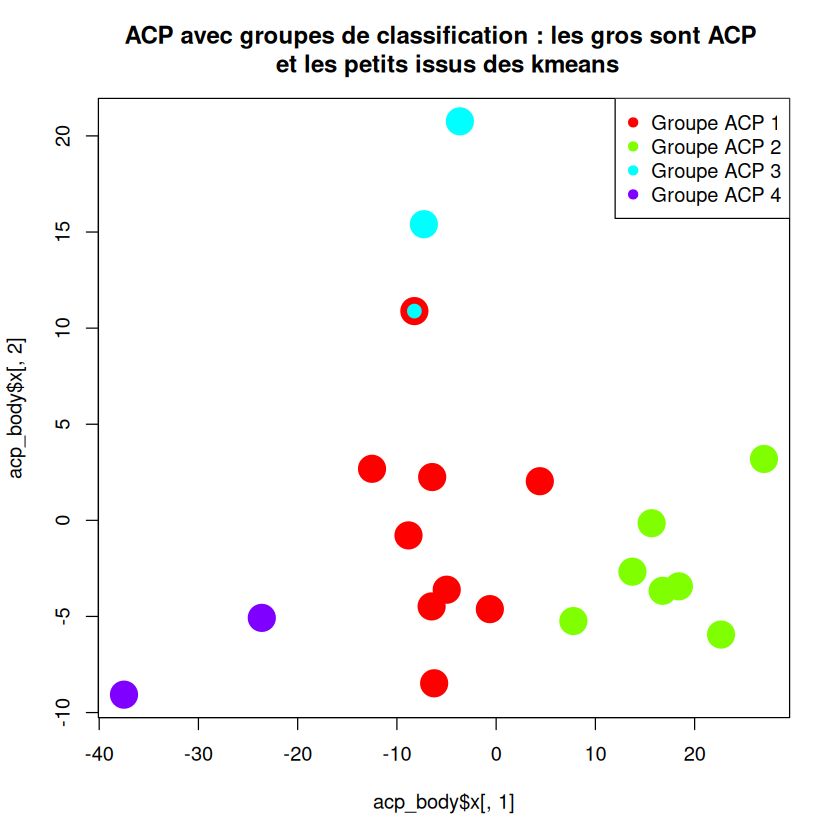

In [74]:
##### Q1
barycentres <- matrix(nrow = 4, ncol = 5)

for (i in 1:4) {
    cl_i <- data_body[which(tree == i), ]
    barycentres[i,] <- colMeans(cl_i)
}

##### Q2
kmeans_body_3 <- kmeans(data_body, centers=barycentres)
kmeans_body_4 <- kmeans(data_body, centers=barycentres)

table(kmeans_body_3$cluster, kmeans_body_4$cluster)
# La matrice est diagonale : ce n'est plus aléatoire

##### Q3
table(kmeans_body_3$cluster, tree)

par(bg = "white")
plot(acp_body$x[,1], acp_body$x[,2], 
     col = rainbow(4)[tree], 
     pch = 19,
     cex = 3,
     main = "ACP avec groupes de classification : les gros sont ACP \n et les petits issus des kmeans")

# Ajouter une légende
legend("topright", 
       legend = paste("Groupe ACP", 1:4), 
       col = rainbow(4), 
       pch = 19)

points(acp_body$x[,1], acp_body$x[,2], 
     col = rainbow(4)[kmeans_body_3$cluster], 
     pch = 19,
     cex = 1.5,)


## 2. Données `body` complètes

Les données sont consituées de 24 variables quantitatives (diamètres, circonférence, âge, taille, poids, ...) mesurées chez 507 individus hommes et femmes (le sexe étant précisé dans la variable `gender`).

In [97]:
data_body_full <- read.table("data/data-body.csv", sep=";", dec=",", header=TRUE)

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Procéder à une classification ascendante hiérarchique (distance euclidienne et critère de Ward) sur les individus et représenter le dendrogramme associé.</li>
        <li>En combien de groupes classeriez-vous les individus ?</li>
        <li>Comparer les groupes de la classification à la variable <code>gender</code> à l'aide d'une table.</li>
        <li>Proposer plusieurs façons de caractériser chacun des groupes de la classification (individus moyens par groupe, ACP, ...).</li>
    </ol>
</div>

<span style="color: skyblue; font-weight: bold;"> Question 1</span>

In [ ]:
distances = dist(data_body_full)
help(hclust)

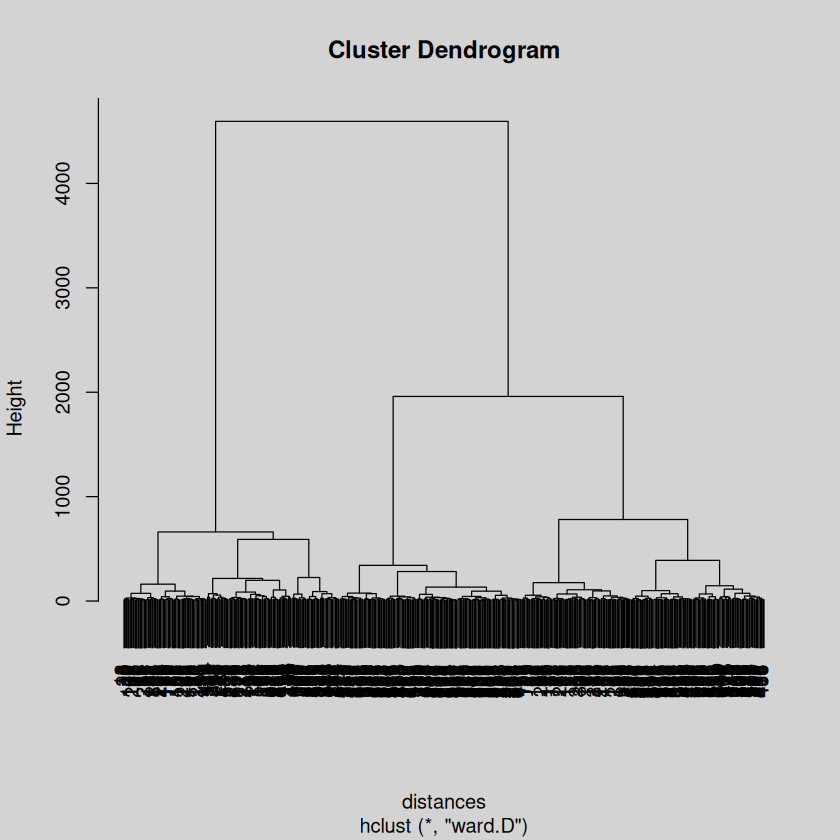

In [86]:
cah_full_body <- hclust(distances, method = "ward.D")

par(bg = "lightgrey")
plot(cah_full_body)

<span style="color: skyblue; font-weight: bold;"> Question 2</span>

Le premier guess serait k = 6 ? En dessous on est à des niveaux trop granulaires

<span style="color: skyblue; font-weight: bold;"> Question 3</span>

In [99]:
tree <- cutree(cah_full_body, k= 6)

table(data_body_full$gender, tree)

   tree
      1   2   3   4   5   6
  F   1   0  12 103 138   6
  M  85  66  55   3   6  32

<span style="color: skyblue; font-weight: bold;"> Question 4</span>

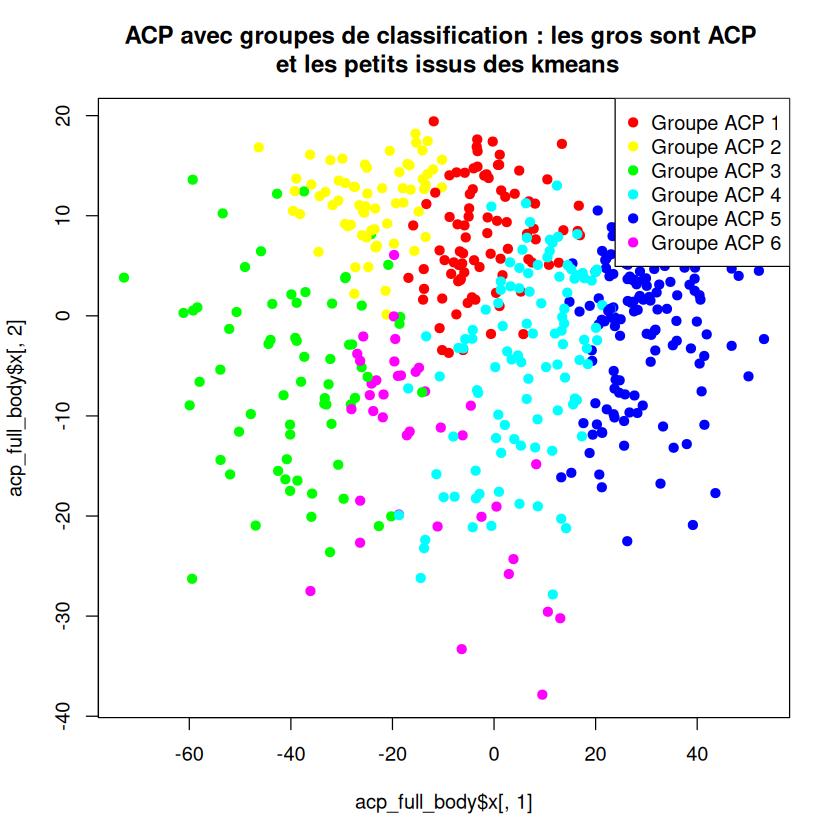

In [110]:
data_body_full$gender <- ifelse(data_body_full$gender == "M", 1, 0)

acp_full_body = prcomp(data_body_full)

par(bg = "white")
par(bg = "white")
plot(acp_full_body$x[,1], acp_full_body$x[,2], 
     col = rainbow(6)[tree], 
     pch = 19,
     cex = 1,
     main = "ACP avec groupes de classification : les gros sont ACP \n et les petits issus des kmeans")

# Ajouter une légende
legend("topright", 
       legend = paste("Groupe ACP", 1:6), 
       col = rainbow(6), 
       pch = 19)

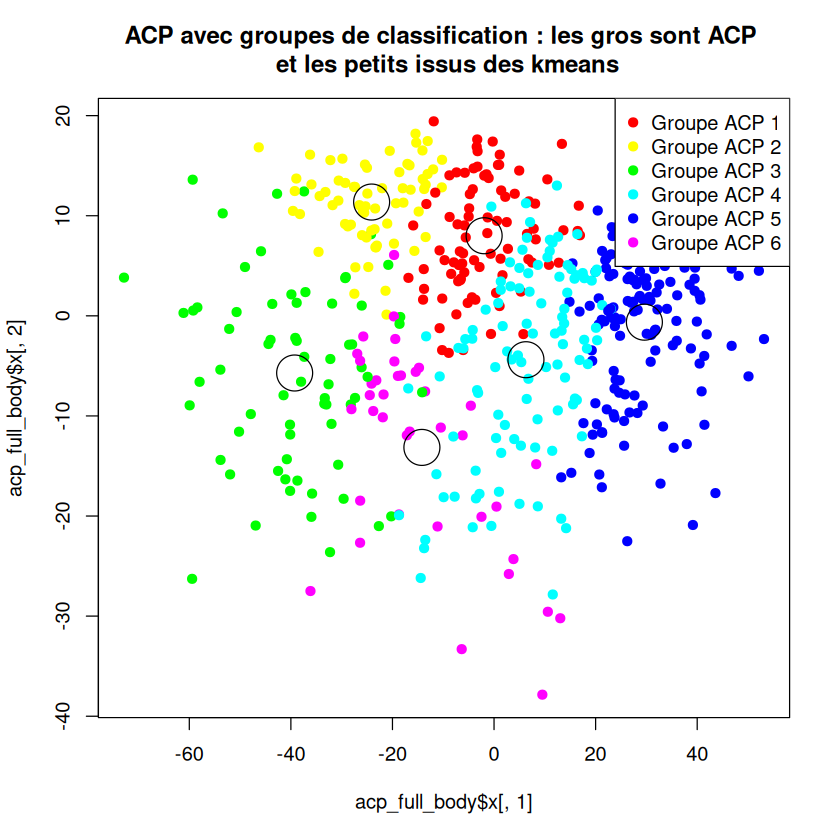

In [118]:
barycentres <- matrix(nrow = 6, ncol = length(colnames(data_body_full)))

for (i in 1:6) {
    cl_i <- data_body_full[which(tree == i), ]
    barycentres[i,] <- colMeans(cl_i)
}

bary_proj <- scale(barycentres, center = acp_full_body$center, scale = acp_full_body$scale) %*% acp_full_body$rotation


par(bg = "white")
par(bg = "white")
plot(acp_full_body$x[,1], acp_full_body$x[,2], 
     col = rainbow(6)[tree], 
     pch = 19,
     cex = 1,
     main = "ACP avec groupes de classification : les gros sont ACP \n et les petits issus des kmeans")

points(bary_proj[,1], bary_proj[,2], 
       col = "black", 
       pch = 21,       # par exemple un gros "étoile"
       cex = 4)

# Ajouter une légende
legend("topright", 
       legend = paste("Groupe ACP", 1:6), 
       col = rainbow(6), 
       pch = 19)
